# Dual-codebook VQ-VAE: speaker supervision and unsupervised phoneme learning
This notebook reproduces the controlled A/B experiment. A uses speaker CE on the pre-quantized speaker representation; B has the identical model and training protocol with CE weight zero. Phoneme identity is used only after training and selection for evaluation and train-fitted code mapping.

The original ten speakers are retained, split independently by token into 80/10/10. Three additional speakers (seed 2026) are held out entirely. Imputation, standardization, initialization and PCA use training data only. Familiar-speaker token splits are not grouped by utterance. No phoneme classification accuracy is used to tune lambda.

In [1]:
from pathlib import Path
import sys, json, runpy, subprocess
import pandas as pd
from dataclasses import asdict
from IPython.display import display, Markdown, Image
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
CONFIG_PATH = ROOT / 'src/configs/dual_vq.py'
config = runpy.run_path(str(CONFIG_PATH))['CONFIG']
print('Interpreter:', sys.executable)
display(asdict(config))
# Use the Anaconda lffl kernel. Set RESUME_RUN=None to launch a fresh full experiment.
RESUME_RUN = ROOT / 'outputs/dual_vq/20260928_190154_268b85'

Interpreter: C:\Users\46021\.conda\envs\lffl\python.exe


{'data': {'csv_path': 'metadata_vowels_acoustics.csv',
  'features': ('f0_median_hz', 'f1_hz', 'f2_hz', 'f3_hz', 'duration_s'),
  'n_speakers': 10,
  'speaker_ids': None,
  'seed': 2026,
  'split': (0.8, 0.1, 0.1),
  'log_features': False},
 'training_speakers': ('jvs003',
  'jvs009',
  'jvs018',
  'jvs036',
  'jvs037',
  'jvs038',
  'jvs046',
  'jvs061',
  'jvs065',
  'jvs078'),
 'heldout_count': 3,
 'hidden_dims': (128, 128),
 'embedding_dim': 8,
 'commitment': 0.25,
 'lambdas': (0.1, 1.0, 10.0),
 'selection_seeds': (42, 43, 44),
 'seeds': (42, 43, 44, 45, 46),
 'baseline_seeds': (42, 43, 44),
 'selection_epochs': 40,
 'epochs': 80,
 'pretrain_epochs': 10,
 'batch_size': 512,
 'learning_rate': 0.001,
 'workers': 2,
 'threads': 1,
 'output_dir': 'outputs/dual_vq'}

## Prespecified model and selection
Each encoder: 5 → 128 ReLU → 128 ReLU → 8. Nearest-neighbor codebooks have 5 phoneme codes and 10 speaker codes. Decoder: 16 → 128 ReLU → 128 ReLU → 5. A linear 10-way head sees only pre-quantized h_s.

Loss = mean reconstruction squared error + sum over branches of [codebook MSE + 0.25 commitment MSE] + lambda × speaker CE. Codebooks use Adam gradients (not EMA); reconstruction uses h + (e-h).detach(). Initialization: 10 continuous-autoencoder epochs, then separate K-means++ (10 restarts) on training representations.

Compare lambda 0.1, 1, 10 over three seeds for 40 epochs. Selection score: validation MSE + 0.1(1 − NMI(K_s;S)) + 0.05(sum of unused-code fractions). No phoneme labels enter this score. Final A/B: five matched seeds, 80 epochs, checkpoint selected by validation reconstruction MSE. Identical initialization and minibatch hashes are verified. Original GMVAE, shared-w GMVAE, and classifier are rerun for three seeds; 15-NN is deterministic and run once.

In [2]:
command = [sys.executable, str(ROOT/'src/train_vq.py'), '--config', str(CONFIG_PATH)]
if RESUME_RUN is not None:
    command += ['--resume', str(RESUME_RUN)]
process = subprocess.Popen(command, cwd=ROOT, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
run_dir = RESUME_RUN
for line in process.stdout:
    print(line, end='')
    if line.startswith('RUN DIRECTORY: '):
        run_dir = Path(line.strip().split('RUN DIRECTORY: ', 1)[1])
assert process.wait() == 0, 'Experiment failed; inspect the saved training logs.'
assert (run_dir/'complete.json').exists()
print('Completed:', run_dir)

COMPLETE: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\dual_vq\20260928_190154_268b85


Completed: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\dual_vq\20260928_190154_268b85


In [3]:
data_info = json.loads((run_dir/'data.json').read_text())
display(pd.DataFrame(data_info['speaker_counts']).fillna(0).astype(int))
display(pd.DataFrame(data_info['phoneme_counts']))
print('Absent training categories:', data_info['absent_training_phonemes'])
import joblib
cache = joblib.load(run_dir/'vq_train_val.joblib')
assert set(cache) == {'x', 'speaker', 'n_phonemes'}
assert set(cache['x']) == {'train', 'val'}
print('VQ training cache has no phoneme identities and no test arrays.')
display(json.loads((run_dir/'selection.json').read_text()))

,train,val,test_seen,test_unseen
jvs003,3667,458,459,0
jvs009,3710,464,464,0
jvs018,3782,473,473,0
jvs036,3696,462,462,0
jvs037,3622,453,453,0
jvs038,3642,455,456,0
jvs046,3673,459,460,0
jvs061,3702,463,463,0
jvs065,3704,463,463,0
jvs078,3665,458,459,0


,train,val,test_seen,test_unseen
a,9017,1129,1144,3340
e,5201,652,686,1977
i,6327,756,785,2322
o,9610,1213,1162,3524
u,6708,858,835,2523


Absent training categories: []
VQ training cache has no phoneme identities and no test arrays.


{'lambda_s': 0.1,
 'ranking': {'0.1': 0.2822607728512432,
  '1.0': 0.29213549244435116,
  '10.0': 0.35971689874482293},
 'phoneme_labels_used': False,
 'test_results_used': False}

In [4]:
metrics = pd.read_csv(run_dir/'metrics.csv')
display(metrics.groupby(['method','split'])[['phoneme_accuracy','speaker_classifier_accuracy','speaker_code_accuracy','mse']].agg(['mean','std']))
paired = pd.read_csv(run_dir/'paired_differences.csv')
display(paired)
display(paired.groupby('split').agg({m:['mean','std'] for m in ['phoneme_accuracy','phi_phi_nmi','phi_phi_ari','phi_s_nmi']}))
# Speaker-classifier accuracy is undefined for unseen identities.
assert metrics.loc[metrics.split.eq('test_unseen'),'speaker_classifier_accuracy'].isna().all()

phoneme_accuracy            \
                                       mean       std   
method         split                                    
A              test_seen           0.391847  0.111260   
               test_unseen         0.392971  0.110819   
B              test_seen           0.362229  0.097903   
               test_unseen         0.357562  0.093201   
classifier     test_seen           0.816710  0.001627   
               test_unseen         0.783185  0.003818   
gmvae          test_seen           0.384938  0.017156   
               test_unseen         0.359759  0.045432   
gmvae_shared_w test_seen           0.373085  0.081601   
               test_unseen         0.352209  0.089823   
knn            test_seen           0.820035       NaN   
               test_unseen         0.783794       NaN   

                           speaker_classifier_accuracy            \
                                                  mean       std   
method         split                                               
A              test_seen                      0.392585  0.015311   
               test_unseen                         NaN       NaN   
B              test_seen                           NaN       NaN   
               test_unseen                         NaN       NaN   
classifier     test_seen                      0.504481  0.005546   
               test_unseen                         NaN       NaN   
gmvae          test_seen                           NaN       NaN   
               test_unseen                         NaN       NaN   
gmvae_shared_w test_seen                           NaN       NaN   
               test_unseen                         NaN       NaN   
knn            test_seen                      0.505204       NaN   
               test_unseen                         NaN       NaN   

                           speaker_code_accuracy                 mse            
                                            mean       std      mean       std  
method         split                                                            
A              test_seen                0.217129  0.024499  0.201244  0.006699  
               test_unseen                   NaN       NaN  0.200723  0.012531  
B              test_seen                0.196791  0.024891  0.201744  0.003118  
               test_unseen                   NaN       NaN  0.196436  0.006184  
classifier     test_seen                     NaN       NaN       NaN       NaN  
               test_unseen                   NaN       NaN       NaN       NaN  
gmvae          test_seen                0.187916  0.021650  0.021680  0.000246  
               test_unseen                   NaN       NaN  0.024066  0.000275  
gmvae_shared_w test_seen                0.203599  0.007029  0.021014  0.000529  
               test_unseen                   NaN       NaN  0.023077  0.000317  
knn            test_seen                     NaN       NaN       NaN       NaN  
               test_unseen                   NaN       NaN       NaN       NaN

,seed,split,phoneme_accuracy,phi_phi_nmi,phi_phi_ari,phi_s_nmi,s_phi_nmi,s_s_nmi,mse
0,42,test_seen,-0.002602,-0.006426,-0.002963,-0.017378,-0.021818,0.010295,-0.005982
1,42,test_unseen,-0.003288,-0.016913,-0.019059,0.009823,-0.038329,0.026149,0.004013
2,43,test_seen,0.007589,0.010483,0.014477,0.002679,0.000779,0.024901,0.000783
3,43,test_unseen,0.010887,0.011082,0.008578,-0.003917,-0.001995,0.032036,-0.002268
4,44,test_seen,0.093669,0.112852,0.111821,-0.042860,-0.066191,0.062909,-0.006041
5,44,test_unseen,0.125968,0.129980,0.109458,-0.063462,-0.052755,0.045154,-0.002675
6,45,test_seen,0.007155,0.022805,0.016853,-0.008099,-0.036855,0.046342,0.004641
7,45,test_unseen,-0.017975,0.050377,0.051991,0.007708,-0.066599,0.055034,0.010822
8,46,test_seen,0.042281,0.107634,0.081869,-0.013957,-0.055625,0.045680,0.004100
9,46,test_unseen,0.061450,0.118616,0.104242,0.002760,-0.073454,0.022783,0.011544


phoneme_accuracy           phi_phi_nmi           phi_phi_ari  \
                        mean       std        mean       std        mean   
split                                                                      
test_seen           0.029618  0.039657    0.049469  0.056471    0.044411   
test_unseen         0.035408  0.058796    0.058628  0.064662    0.051042   

                      phi_s_nmi            
                  std      mean       std  
split                                      
test_seen    0.049616 -0.015923  0.016873  
test_unseen  0.056923 -0.009418  0.030671

Report: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\dual_vq\20260928_190154_268b85\REPORT.md


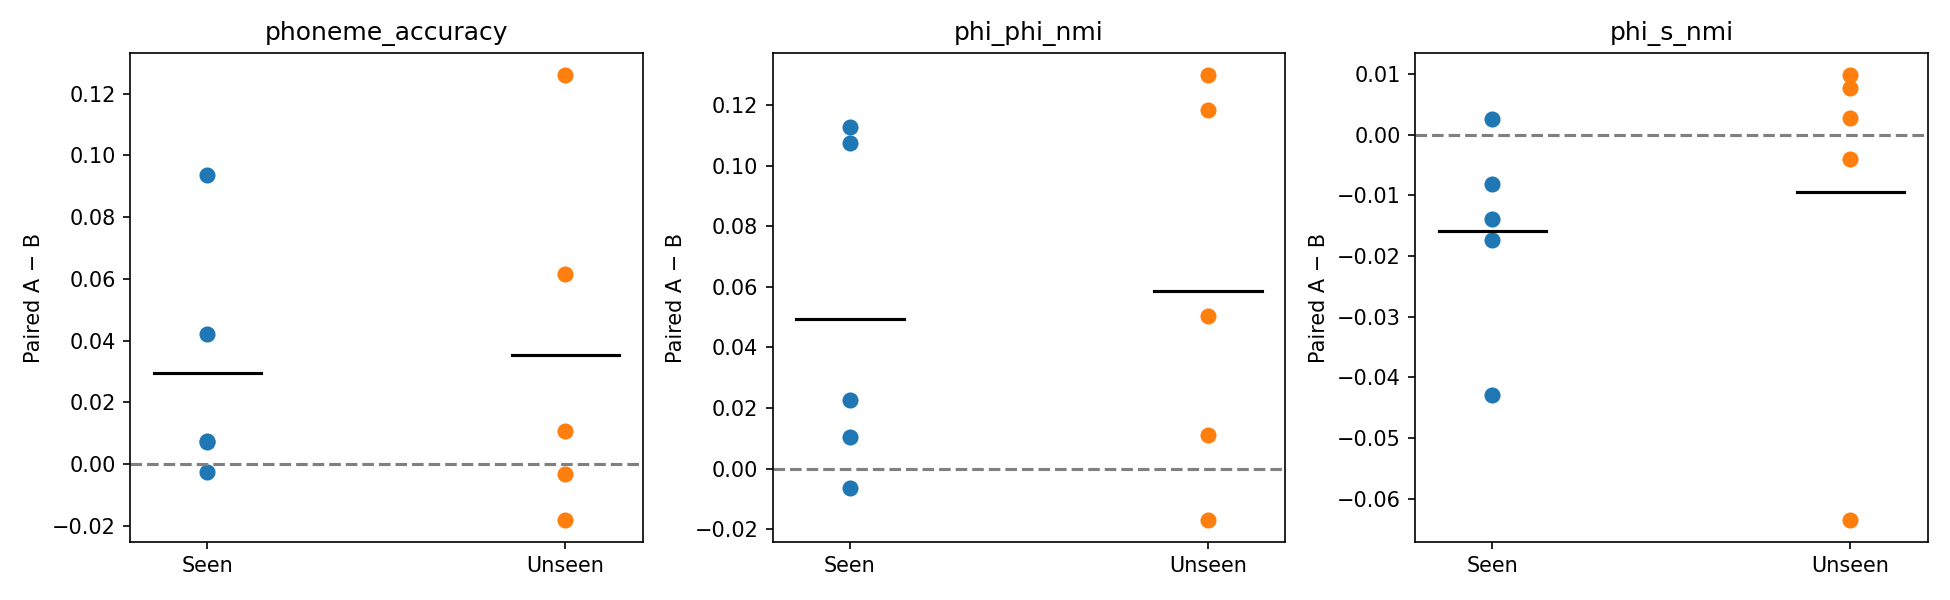

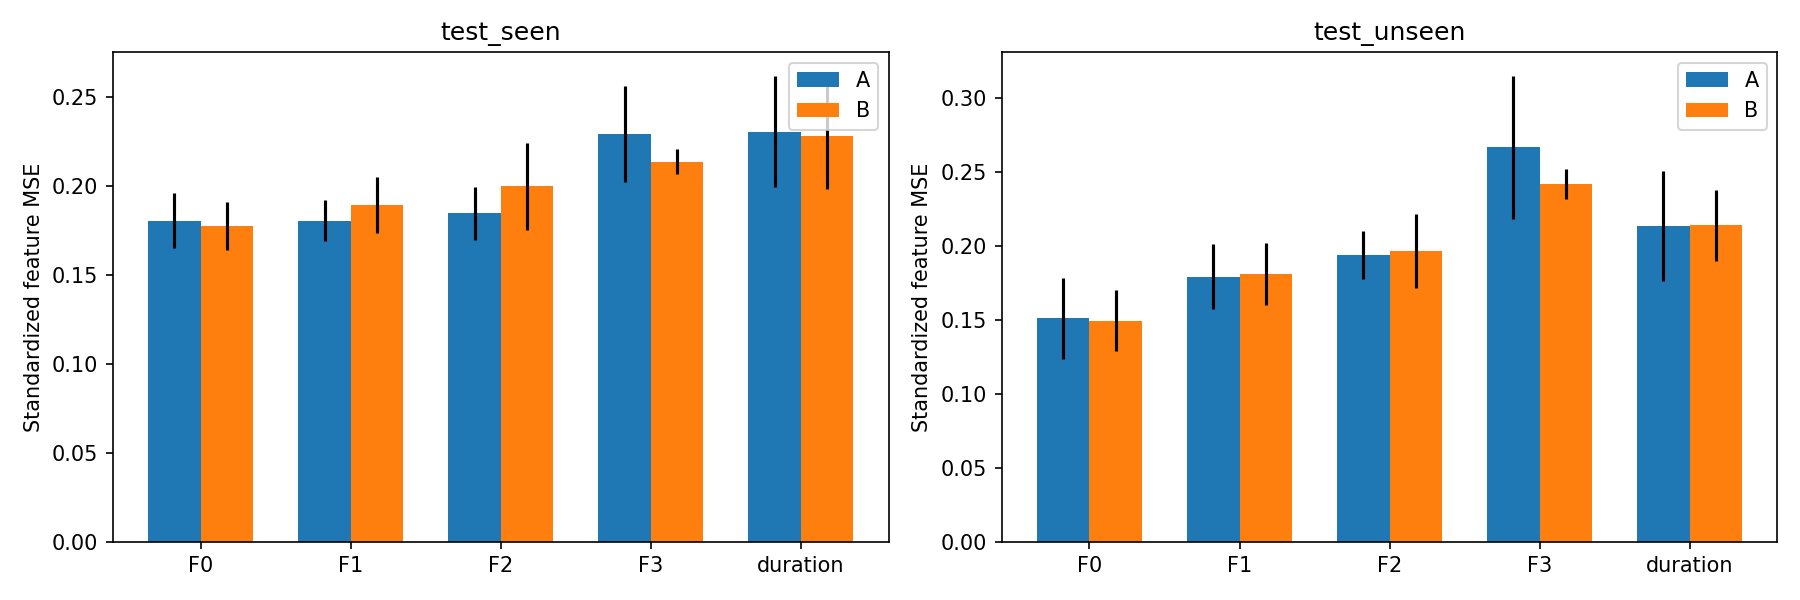

# Dual-codebook VQ-VAE experiment

## Design and data

Run `20260928_190154_268b85`. Data seed 2026; CSV SHA256 `71dfbfe4886fc9fb457f01cff87bb5daf5d91bd0023f701b11d6a3811af04985`. The original ten speakers were retained; three additional speakers were sampled without replacement from the remainder using seed 2026. Each familiar speaker was randomly split independently into 80/10/10 (rounding accounts for integer counts). This differs from the old jointly stratified token split, so every comparison below was rerun on the new split. Tokens are the split unit; utterances were not grouped. The unseen-speaker test contains all selected tokens.

Exact split totals: train=36,863, val=4,608, test_seen=4,612, test_unseen=13,686.

| Speaker | train | val | test_seen | test_unseen |
| --- | --- | --- | --- | --- |
| jvs003 | 3667 | 458 | 459 | 0 |
| jvs009 | 3710 | 464 | 464 | 0 |
| jvs018 | 3782 | 473 | 473 | 0 |
| jvs036 | 3696 | 462 | 462 | 0 |
| jvs037 | 3622 | 453 | 453 | 0 |
| jvs038 | 3642 | 455 | 456 | 0 |
| jvs046 | 3673 | 459 | 460 | 0 |
| jvs061 | 3702 | 463 | 463 | 0 |
| jvs065 | 3704 | 463 | 463 | 0 |
| jvs078 | 3665 | 458 | 459 | 0 |
| jvs004 | 0 | 0 | 0 | 4566 |
| jvs020 | 0 | 0 | 0 | 4631 |
| jvs086 | 0 | 0 | 0 | 4489 |

Phoneme counts (labels used only for reporting/evaluation in VQ experiments):

| Vowel | train | val | test_seen | test_unseen |
| --- | --- | --- | --- | --- |
| a | 9017 | 1129 | 1144 | 3340 |
| e | 5201 | 652 | 686 | 1977 |
| i | 6327 | 756 | 785 | 2322 |
| o | 9610 | 1213 | 1162 | 3524 |
| u | 6708 | 858 | 835 | 2523 |

Phoneme percentages:

| Vowel | train | val | test_seen | test_unseen |
| --- | --- | --- | --- | --- |
| a | 24.46 | 24.5 | 24.8 | 24.4 |
| e | 14.11 | 14.15 | 14.87 | 14.45 |
| i | 17.16 | 16.41 | 17.02 | 16.97 |
| o | 26.07 | 26.32 | 25.2 | 25.75 |
| u | 18.2 | 18.62 | 18.1 | 18.43 |

Categories absent from training: none. Nonfinite/nonpositive features become missing; training medians impute them and training means/SDs standardize all four splits. No log transform. Missing F0 tokens are retained; reconstruction measures the imputed target as in the previous experiments. The training and unseen F0 missing/invalid counts are 12011 and 5578, respectively.

## Architecture and objective

Separate encoders: 5 → hidden layers [128, 128] (ReLU) → 8. Codebooks: K_phi=5, K_s=10, each with 8-dimensional embeddings. Decoder: concatenate 16 → hidden layers [128, 128] (ReLU) → 5 linear outputs. Auxiliary head: h_s (8) → 10 logits. Total parameters: 56,167; the 90-parameter classifier is present but unoptimized and unevaluated in B. Speaker identity is a CE target only. No phoneme loss or adversarial loss is used. B’s plotted CE is a diagnostic of its inactive head and does not contribute to its loss or checkpoint selection.

`L = mean((x − x_hat)^2) + Σ_b [mean((sg(h_b) − e_b)^2) + 0.25 mean((h_b − sg(e_b))^2)] + lambda_s CE(C_s(h_s), s)`

Means average over batch and coordinates (reconstruction averages over all five features). Quantization picks the nearest embedding in squared Euclidean distance. Straight-through output is `h + (e − h).detach()`: reconstruction gradients reach the encoder; detached encoder targets update codebooks through their own loss. Codebooks use gradient descent, not EMA. Both conditions receive 10 epochs of continuous autoencoder initialization and separate training-only K-means++ (10 restarts) on each encoder output. No dead-code resets or extra regularizers. Adam learning rate 0.001; batch 512; gradient clipping 10; no weight decay; CPU, one thread per worker.

## Hyperparameter selection and matched ablation

Speaker weights [0.1, 1.0, 10.0] were compared for 40 epochs at seeds [42, 43, 44]. Each checkpoint minimizes validation reconstruction MSE. Configuration score is validation MSE + 0.1(1 − NMI(K_s;S)) + 0.05[(1 − active_phi/5) + (1 − active_s/10)], averaged over selection seeds. These weights were prespecified. Selected lambda_s=0.1. No phoneme identities or test metrics were used for selection. A uses the selected weight and B uses zero. Both train for 80 epochs at seeds [42, 43, 44, 45, 46], selecting minimum validation reconstruction checkpoints. Both see identical initialization and minibatch sequences, verified by hashes; selected epochs can differ. The final seeds overlap selection seeds, so the comparison is exploratory rather than an independent replication.

| lambda_s | seed | validation_mse | validation_speaker_nmi | selection_score |
| --- | --- | --- | --- | --- |
| 0.1 | 43 | 0.19741 | 0.18936 | 0.27847 |
| 0.1 | 42 | 0.19992 | 0.09354 | 0.29056 |
| 1.0 | 42 | 0.21637 | 0.2303 | 0.29334 |
| 0.1 | 44 | 0.19565 | 0.179 | 0.27775 |
| 1.0 | 43 | 0.22207 | 0.22526 | 0.29954 |
| 1.0 | 44 | 0.20643 | 0.22907 | 0.28352 |
| 10.0 | 42 | 0.2983 | 0.26974 | 0.37133 |
| 10.0 | 43 | 0.28782 | 0.27573 | 0.36024 |
| 10.0 | 44 | 0.27419 | 0.26607 | 0.34758 |

## Main results

Mean ± sample SD across five seeds for the primary A/B comparison. Accuracy columns are percentages. Phoneme and optional familiar-speaker code mappings are fitted using training labels after training and then frozen for both tests. No classifier accuracy or Hungarian speaker accuracy is defined for unseen speakers.

| Method | Test | n | phoneme_accuracy | speaker_classifier_accuracy | speaker_code_accuracy | mse |
| --- | --- | --- | --- | --- | --- | --- |
| A | seen | 5 | 39.185 ± 11.126 | 39.258 ± 1.531 | 21.713 ± 2.450 | 0.201 ± 0.007 |
| A | unseen | 5 | 39.297 ± 11.082 | — | — | 0.201 ± 0.013 |
| B | seen | 5 | 36.223 ± 9.790 | — | 19.679 ± 2.489 | 0.202 ± 0.003 |
| B | unseen | 5 | 35.756 ± 9.320 | — | — | 0.196 ± 0.006 |

Matched baseline comparison below restricts all neural models, including A/B, to the same three seeds (42, 43, 44). 15-NN is deterministic and run once. Do not confuse these three-seed means with the primary five-seed A/B means above.

| Method | Test | n | phoneme_accuracy | speaker_classifier_accuracy | speaker_code_accuracy | mse |
| --- | --- | --- | --- | --- | --- | --- |
| A | seen | 3 | 41.631 ± 14.212 | 39.621 ± 0.587 | 22.044 ± 3.312 | 0.197 ± 0.003 |
| A | unseen | 3 | 42.708 ± 13.080 | — | — | 0.192 ± 0.004 |
| B | seen | 3 | 38.342 ± 12.865 | — | 19.883 ± 2.683 | 0.200 ± 0.003 |
| B | unseen | 3 | 38.256 ± 12.156 | — | — | 0.192 ± 0.001 |
| gmvae | seen | 3 | 38.494 ± 1.716 | — | 18.792 ± 2.165 | 0.022 ± 0.000 |
| gmvae | unseen | 3 | 35.976 ± 4.543 | — | — | 0.024 ± 0.000 |
| gmvae_shared_w | seen | 3 | 37.308 ± 8.160 | — | 20.360 ± 0.703 | 0.021 ± 0.001 |
| gmvae_shared_w | unseen | 3 | 35.221 ± 8.982 | — | — | 0.023 ± 0.000 |
| classifier | seen | 3 | 81.671 ± 0.163 | 50.448 ± 0.555 | — | — |
| classifier | unseen | 3 | 78.318 ± 0.382 | — | — | — |
| knn | seen | 1 | 82.003 | 50.520 | — | — |
| knn | unseen | 1 | 78.379 | — | — | — |

15-NN and the classifier use phoneme labels in training and are supervised references. Original GMVAE and shared-w GMVAE retain their previous hyperparameters (20 pretraining epochs, up to 100 training epochs, validation-loss early stopping). Their reconstruction uses the decoder at posterior mean z; it is not a discrete-only reconstruction, unlike the VQ models. Non-generative references have no reconstruction metric.

With only two hard codes and no continuous bypass, the VQ decoder can produce at most 5×10=50 distinct reconstruction vectors. The GMVAEs retain a continuous latent z, so lower reconstruction error from a GMVAE would not by itself demonstrate better categorical factorization.

## Paired speaker-supervision effects (A − B)

Per-seed accuracy differences are percentage points; NMI/ARI differences are on their native scale. Positive phi-phoneme metrics and negative phi-speaker NMI are the intended pattern.

| seed | split | phoneme_accuracy | phi_phi_nmi | phi_phi_ari | phi_s_nmi |
| --- | --- | --- | --- | --- | --- |
| 42 | test_seen | -0.2602 | -0.0064 | -0.003 | -0.0174 |
| 42 | test_unseen | -0.3288 | -0.0169 | -0.0191 | 0.0098 |
| 43 | test_seen | 0.7589 | 0.0105 | 0.0145 | 0.0027 |
| 43 | test_unseen | 1.0887 | 0.0111 | 0.0086 | -0.0039 |
| 44 | test_seen | 9.3669 | 0.1129 | 0.1118 | -0.0429 |
| 44 | test_unseen | 12.5968 | 0.13 | 0.1095 | -0.0635 |
| 45 | test_seen | 0.7155 | 0.0228 | 0.0169 | -0.0081 |
| 45 | test_unseen | -1.7975 | 0.0504 | 0.052 | 0.0077 |
| 46 | test_seen | 4.2281 | 0.1076 | 0.0819 | -0.014 |
| 46 | test_unseen | 6.145 | 0.1186 | 0.1042 | 0.0028 |

| Test | phoneme_accuracy | phi_phi_nmi | phi_phi_ari | phi_s_nmi |
| --- | --- | --- | --- | --- |
| test_seen | 2.9618 ± 3.9657 | 0.0495 ± 0.0565 | 0.0444 ± 0.0496 | -0.0159 ± 0.0169 |
| test_unseen | 3.5408 ± 5.8796 | 0.0586 ± 0.0647 | 0.0510 ± 0.0569 | -0.0094 ± 0.0307 |


## Reconstruction by feature

| Method | Test | n | mse_f0_median_hz | mse_f1_hz | mse_f2_hz | mse_f3_hz | mse_duration_s |
| --- | --- | --- | --- | --- | --- | --- | --- |
| A | seen | 5 | 0.181 ± 0.016 | 0.181 ± 0.012 | 0.185 ± 0.015 | 0.229 ± 0.027 | 0.231 ± 0.031 |
| A | unseen | 5 | 0.151 ± 0.027 | 0.179 ± 0.022 | 0.194 ± 0.016 | 0.266 ± 0.049 | 0.213 ± 0.037 |
| B | seen | 5 | 0.177 ± 0.014 | 0.189 ± 0.016 | 0.200 ± 0.024 | 0.214 ± 0.007 | 0.228 ± 0.030 |
| B | unseen | 5 | 0.149 ± 0.021 | 0.181 ± 0.021 | 0.197 ± 0.025 | 0.242 ± 0.010 | 0.214 ± 0.024 |


## Discrete organization and leakage

NMI uses arithmetic normalization; ARI is chance-adjusted. Purity is the sum of each code’s majority-label count divided by tokens. Purity can be high with many codes, especially 10 codes for only 3 unseen identities, so read it alongside NMI/ARI. Seen and unseen speaker metrics involve 10 versus 3 true identities; A/B comparisons within each test set are more directly interpretable than raw cross-set speaker-metric changes. Perplexity is exp(entropy) of hard code occupancy. Usage and rare/unused code IDs are saved per split and seed.

| Method | Test | n | phi_phi_nmi | phi_s_nmi | s_phi_nmi | s_s_nmi |
| --- | --- | --- | --- | --- | --- | --- |
| A | seen | 5 | 0.187 ± 0.140 | 0.065 ± 0.036 | 0.162 ± 0.114 | 0.153 ± 0.043 |
| A | unseen | 5 | 0.185 ± 0.115 | 0.060 ± 0.039 | 0.158 ± 0.082 | 0.185 ± 0.046 |
| B | seen | 5 | 0.137 ± 0.123 | 0.080 ± 0.038 | 0.198 ± 0.116 | 0.115 ± 0.033 |
| B | unseen | 5 | 0.127 ± 0.101 | 0.069 ± 0.037 | 0.205 ± 0.097 | 0.149 ± 0.049 |
| gmvae | seen | 3 | 0.159 ± 0.063 | 0.132 ± 0.027 | 0.200 ± 0.026 | 0.084 ± 0.024 |
| gmvae | unseen | 3 | 0.148 ± 0.073 | 0.147 ± 0.007 | 0.188 ± 0.027 | 0.092 ± 0.008 |
| gmvae_shared_w | seen | 3 | 0.118 ± 0.078 | 0.059 ± 0.039 | 0.136 ± 0.030 | 0.117 ± 0.013 |
| gmvae_shared_w | unseen | 3 | 0.116 ± 0.090 | 0.071 ± 0.063 | 0.123 ± 0.043 | 0.121 ± 0.034 |

| Method | Test | n | phi_phi_ari | phi_phi_purity | s_s_ari | s_s_purity |
| --- | --- | --- | --- | --- | --- | --- |
| A | seen | 5 | 0.155 ± 0.127 | 0.450 ± 0.141 | 0.066 ± 0.022 | 0.229 ± 0.024 |
| A | unseen | 5 | 0.161 ± 0.107 | 0.438 ± 0.119 | 0.095 ± 0.029 | 0.593 ± 0.052 |
| B | seen | 5 | 0.110 ± 0.111 | 0.396 ± 0.117 | 0.046 ± 0.017 | 0.210 ± 0.023 |
| B | unseen | 5 | 0.110 ± 0.099 | 0.387 ± 0.096 | 0.080 ± 0.034 | 0.565 ± 0.050 |

| Method | Test | n | phi_active_codes | phi_perplexity | s_active_codes | s_perplexity |
| --- | --- | --- | --- | --- | --- | --- |
| A | seen | 5 | 5.000 ± 0.000 | 4.606 ± 0.127 | 10.000 ± 0.000 | 8.821 ± 0.485 |
| A | unseen | 5 | 5.000 ± 0.000 | 4.150 ± 0.178 | 10.000 ± 0.000 | 7.807 ± 0.850 |
| B | seen | 5 | 5.000 ± 0.000 | 4.602 ± 0.283 | 10.000 ± 0.000 | 8.523 ± 0.659 |
| B | unseen | 5 | 5.000 ± 0.000 | 4.162 ± 0.278 | 10.000 ± 0.000 | 7.761 ± 0.848 |

## Decoder dependence and diagnostics

Branch ablations replace all quantized vectors in that branch with its training-population mean quantized vector. Positive MSE changes indicate decoder dependence; this is a diagnostic intervention and can produce off-codebook inputs.

| Method | Test | n | mse | ablate_phi_mse | ablate_phi_delta | ablate_s_mse | ablate_s_delta |
| --- | --- | --- | --- | --- | --- | --- | --- |
| A | seen | 5 | 0.201 ± 0.007 | 0.537 ± 0.029 | 0.335 ± 0.032 | 0.703 ± 0.021 | 0.501 ± 0.021 |
| A | unseen | 5 | 0.201 ± 0.013 | 0.509 ± 0.029 | 0.308 ± 0.023 | 0.700 ± 0.067 | 0.499 ± 0.076 |
| B | seen | 5 | 0.202 ± 0.003 | 0.546 ± 0.039 | 0.345 ± 0.040 | 0.703 ± 0.041 | 0.501 ± 0.041 |
| B | unseen | 5 | 0.196 ± 0.006 | 0.508 ± 0.052 | 0.311 ± 0.056 | 0.702 ± 0.064 | 0.506 ± 0.061 |

## Interpretation

For seen speakers, speaker supervision changed phoneme accuracy by +2.96 points (positive in 4/5 seeds), phoneme NMI by +0.049, ARI by +0.044, and speaker contamination NMI by -0.016.

For unseen speakers, speaker supervision changed phoneme accuracy by +3.54 points (positive in 3/5 seeds), phoneme NMI by +0.059, ARI by +0.051, and speaker contamination NMI by -0.009.

Condition A: mean phoneme accuracy changes from 39.18% familiar to 39.30% unfamiliar speakers; MSE changes from 0.201 to 0.201. Familiar phoneme-code NMI for phoneme/speaker is 0.187/0.065; speaker-code NMI for phoneme/speaker is 0.162/0.153. Replacing phi/s with their means raises MSE by 0.335/0.501.

Condition B: mean phoneme accuracy changes from 36.22% familiar to 35.76% unfamiliar speakers; MSE changes from 0.202 to 0.196. Familiar phoneme-code NMI for phoneme/speaker is 0.137/0.080; speaker-code NMI for phoneme/speaker is 0.198/0.115. Replacing phi/s with their means raises MSE by 0.345/0.501.

The supervised speaker head achieves 39.26% familiar-speaker accuracy, while the speaker VQ code achieves 21.71% train-mapped accuracy and NMI 0.153. The head acts before quantization: good continuous classification does not guarantee a speaker-organized discrete codebook.

0/20 model/test evaluations have at least one unused code. See occupancy histograms and usage JSON for dominant/rare codes; using every code alone does not prove factorization.

The A/B comparison isolates the added speaker loss under the stated selection procedure. Its conclusion applies to the selected speaker weight and this reconstruction-oriented selection criterion; it does not rule out different effects at other weights. Neither branch is explicitly constrained to exclude the other factor, and the decoder may use either codebook for any acoustic variation. The two unsupervised branches in B have no guaranteed semantic identities; their names indicate intended roles. Five optimization seeds describe initialization variability, not uncertainty across independent speaker samples. There is one held-out speaker trio; token-level splitting among familiar speakers and median-imputed F0 also limit generalization claims.

## Saved diagnostics and reproducibility

Every final A/B seed has learning curves, occupancy histograms, all four contingency matrices, per-speaker code distributions, and PCA plots of both pre-quantized representations colored by both factors. PCA is fitted on training representations; plots subsample at most 3,500 test tokens with a fixed visualization seed. First-seed figures below are prespecified examples, not the best run.






Configuration: `src/configs/dual_vq.py`; CLI: `python src/train_vq.py --config src/configs/dual_vq.py`; resume with `--resume RUN_DIRECTORY`. Results: `metrics.csv`, `summary.csv`, `paired_differences.csv`; exact split: `split_manifest.csv`; preprocessing: `preprocessing.joblib`; plan/source hashes: `plan.json`; environment: `environment.json`; training code snapshot: `source_snapshot/`. Each trial retains initialization, best checkpoint, validation record, histories and logs. Test representations and mappings are saved. Regenerate this report/figures with `python src/vq_report.py RUN_DIRECTORY`.

### Diagnostic example: A, prespecified seed 42

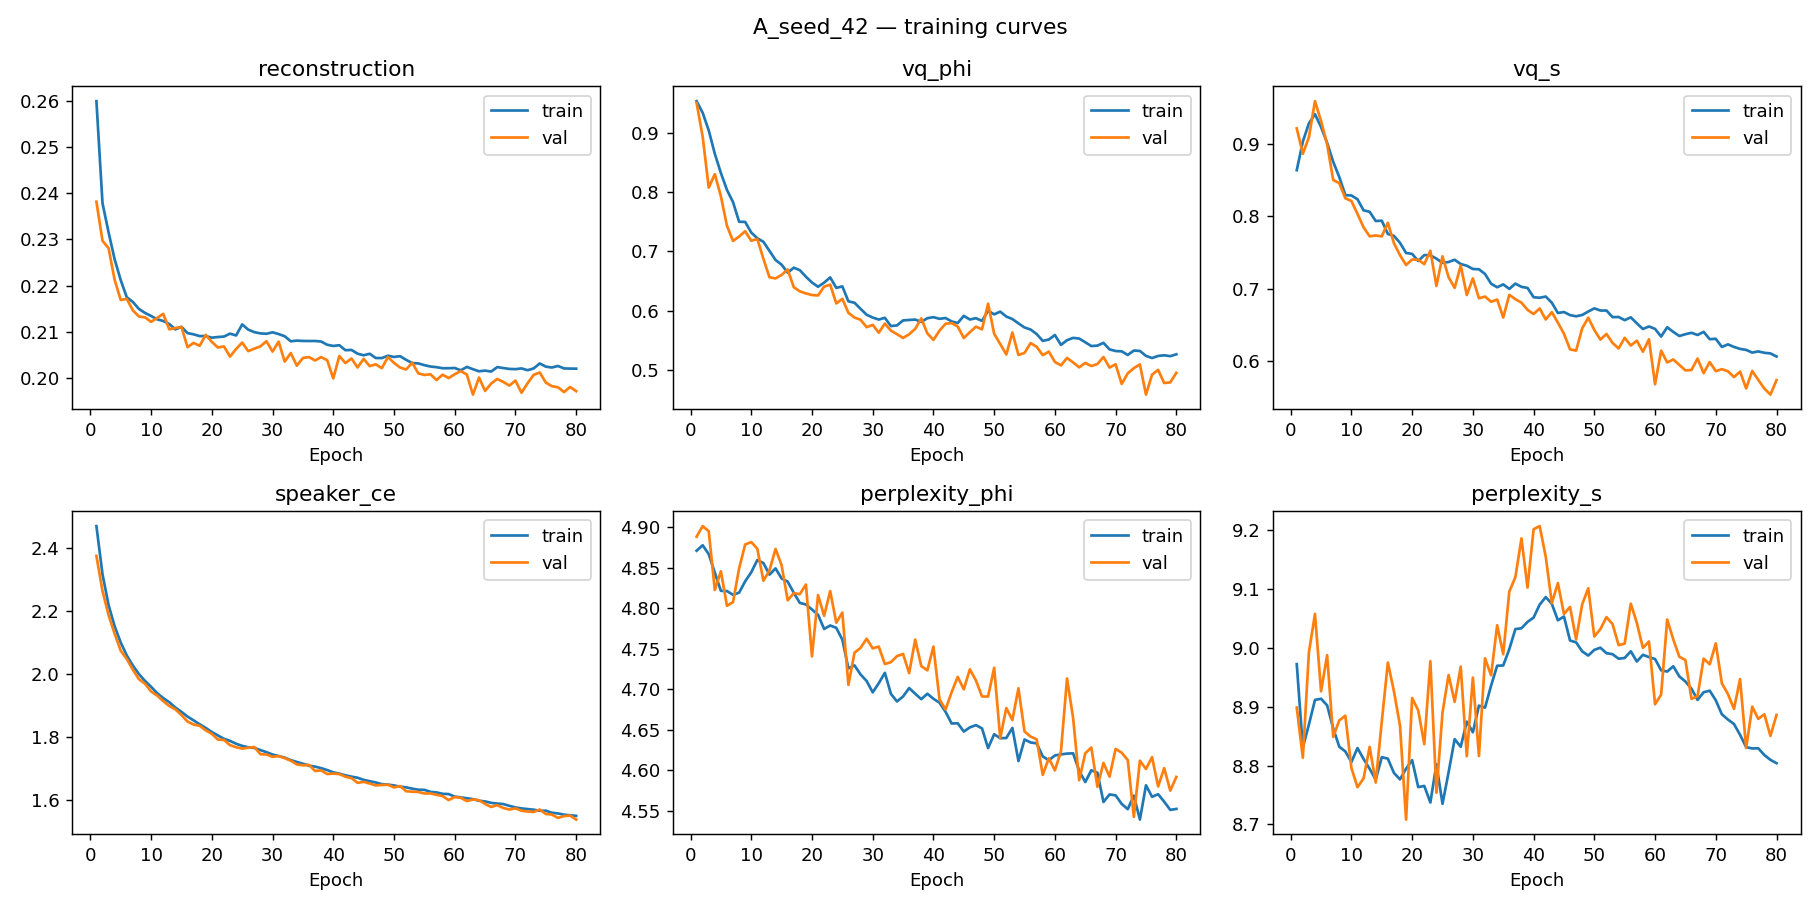

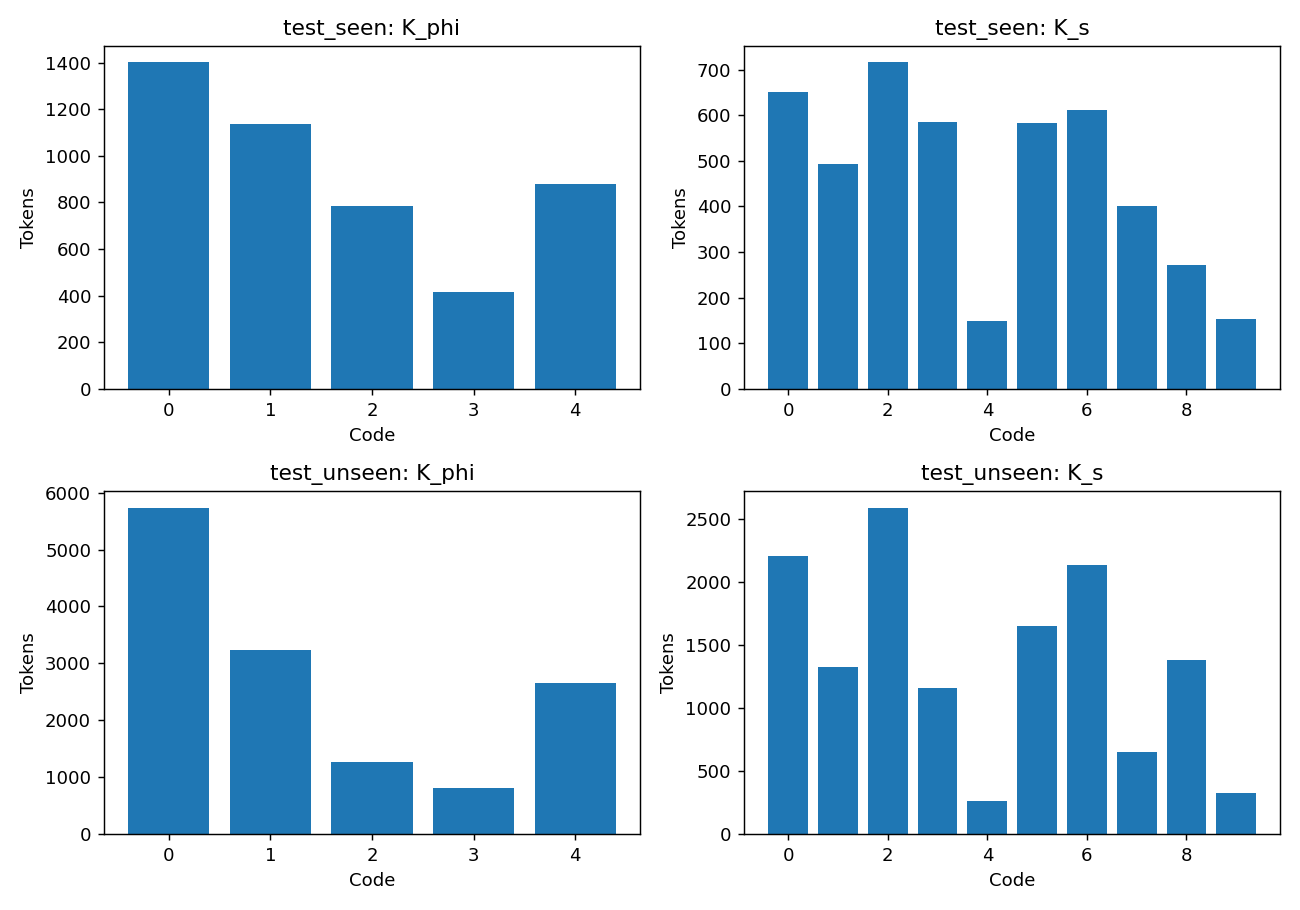

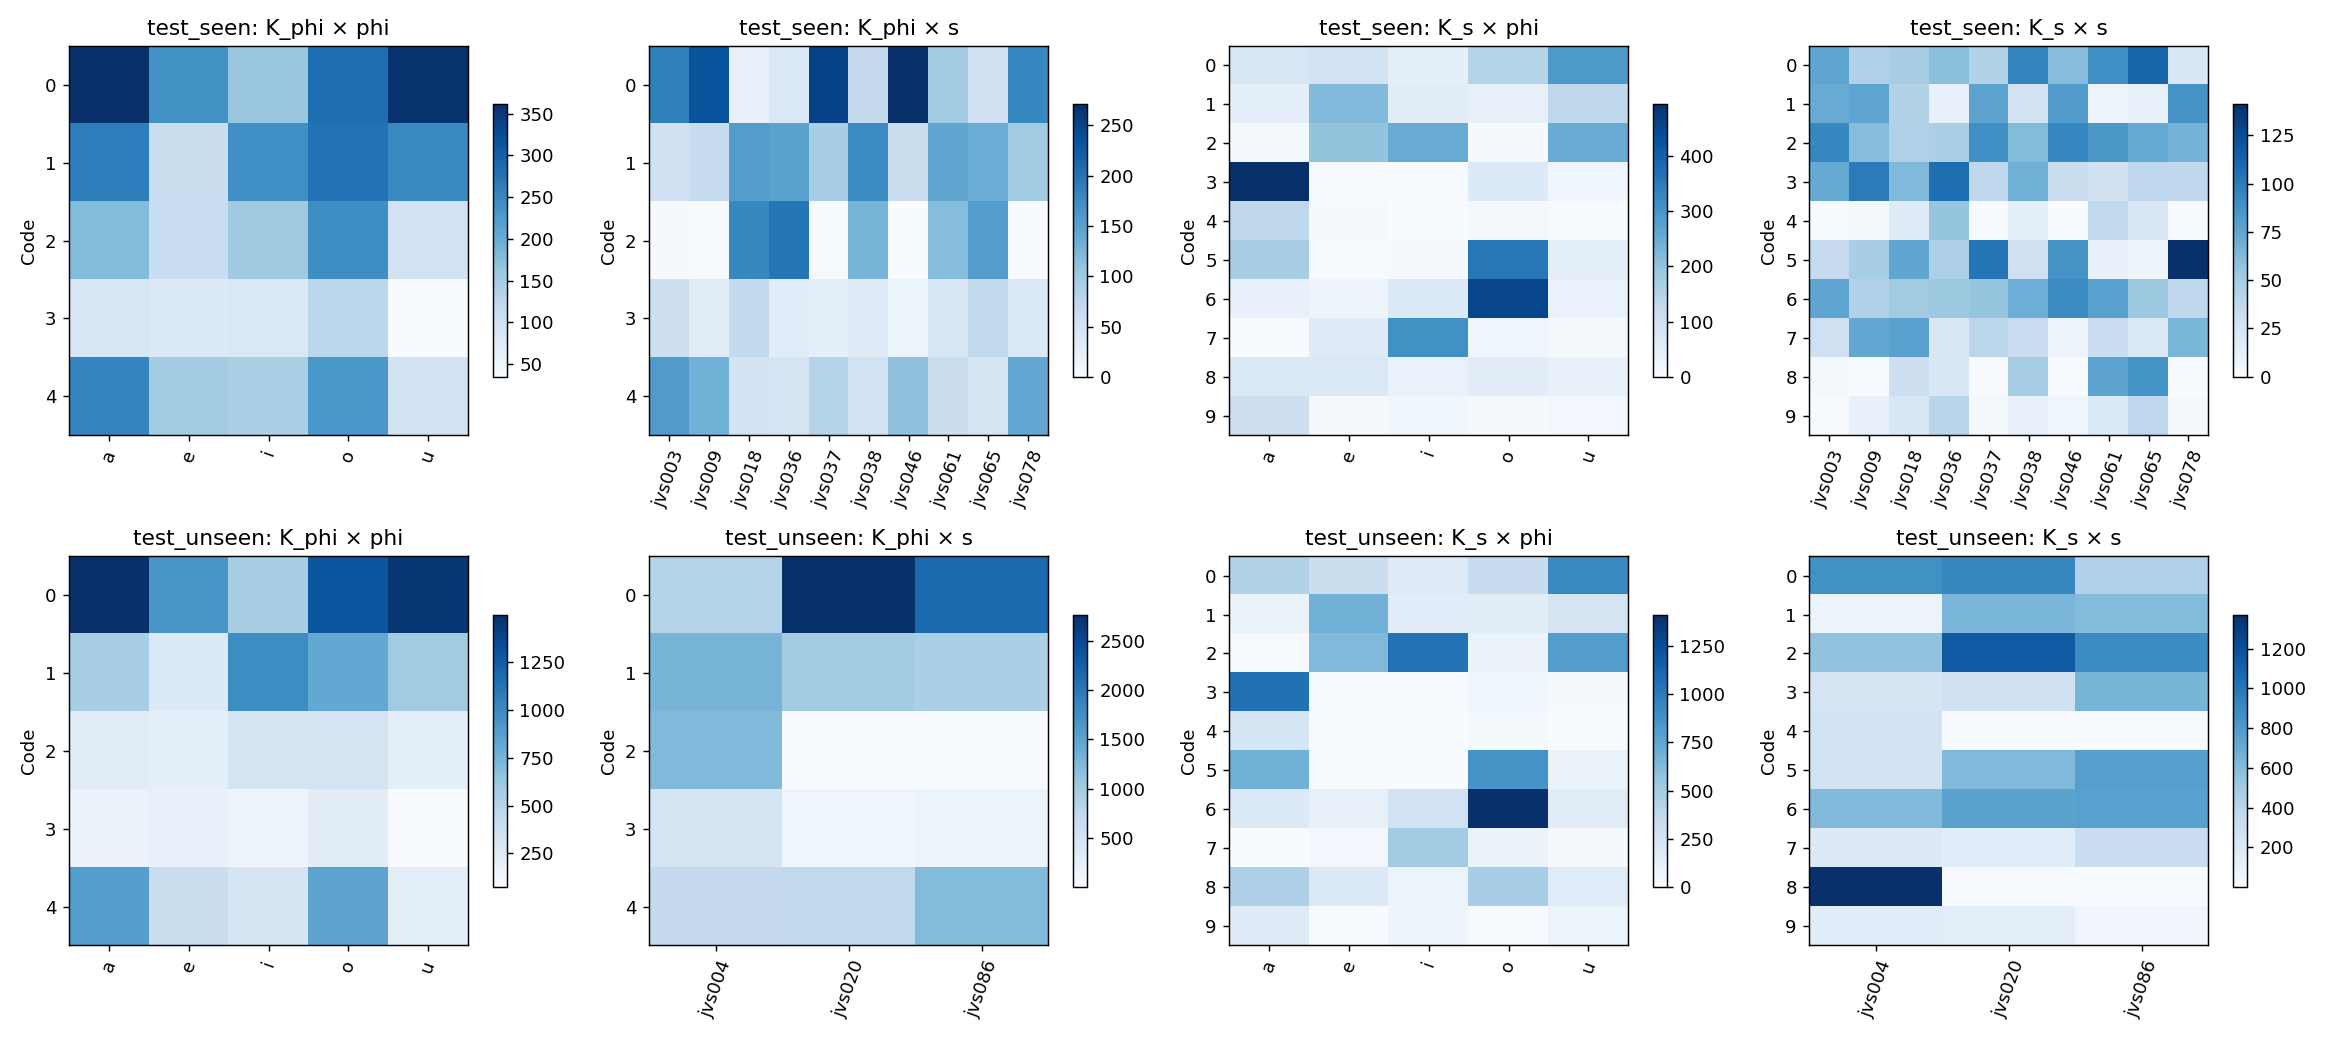

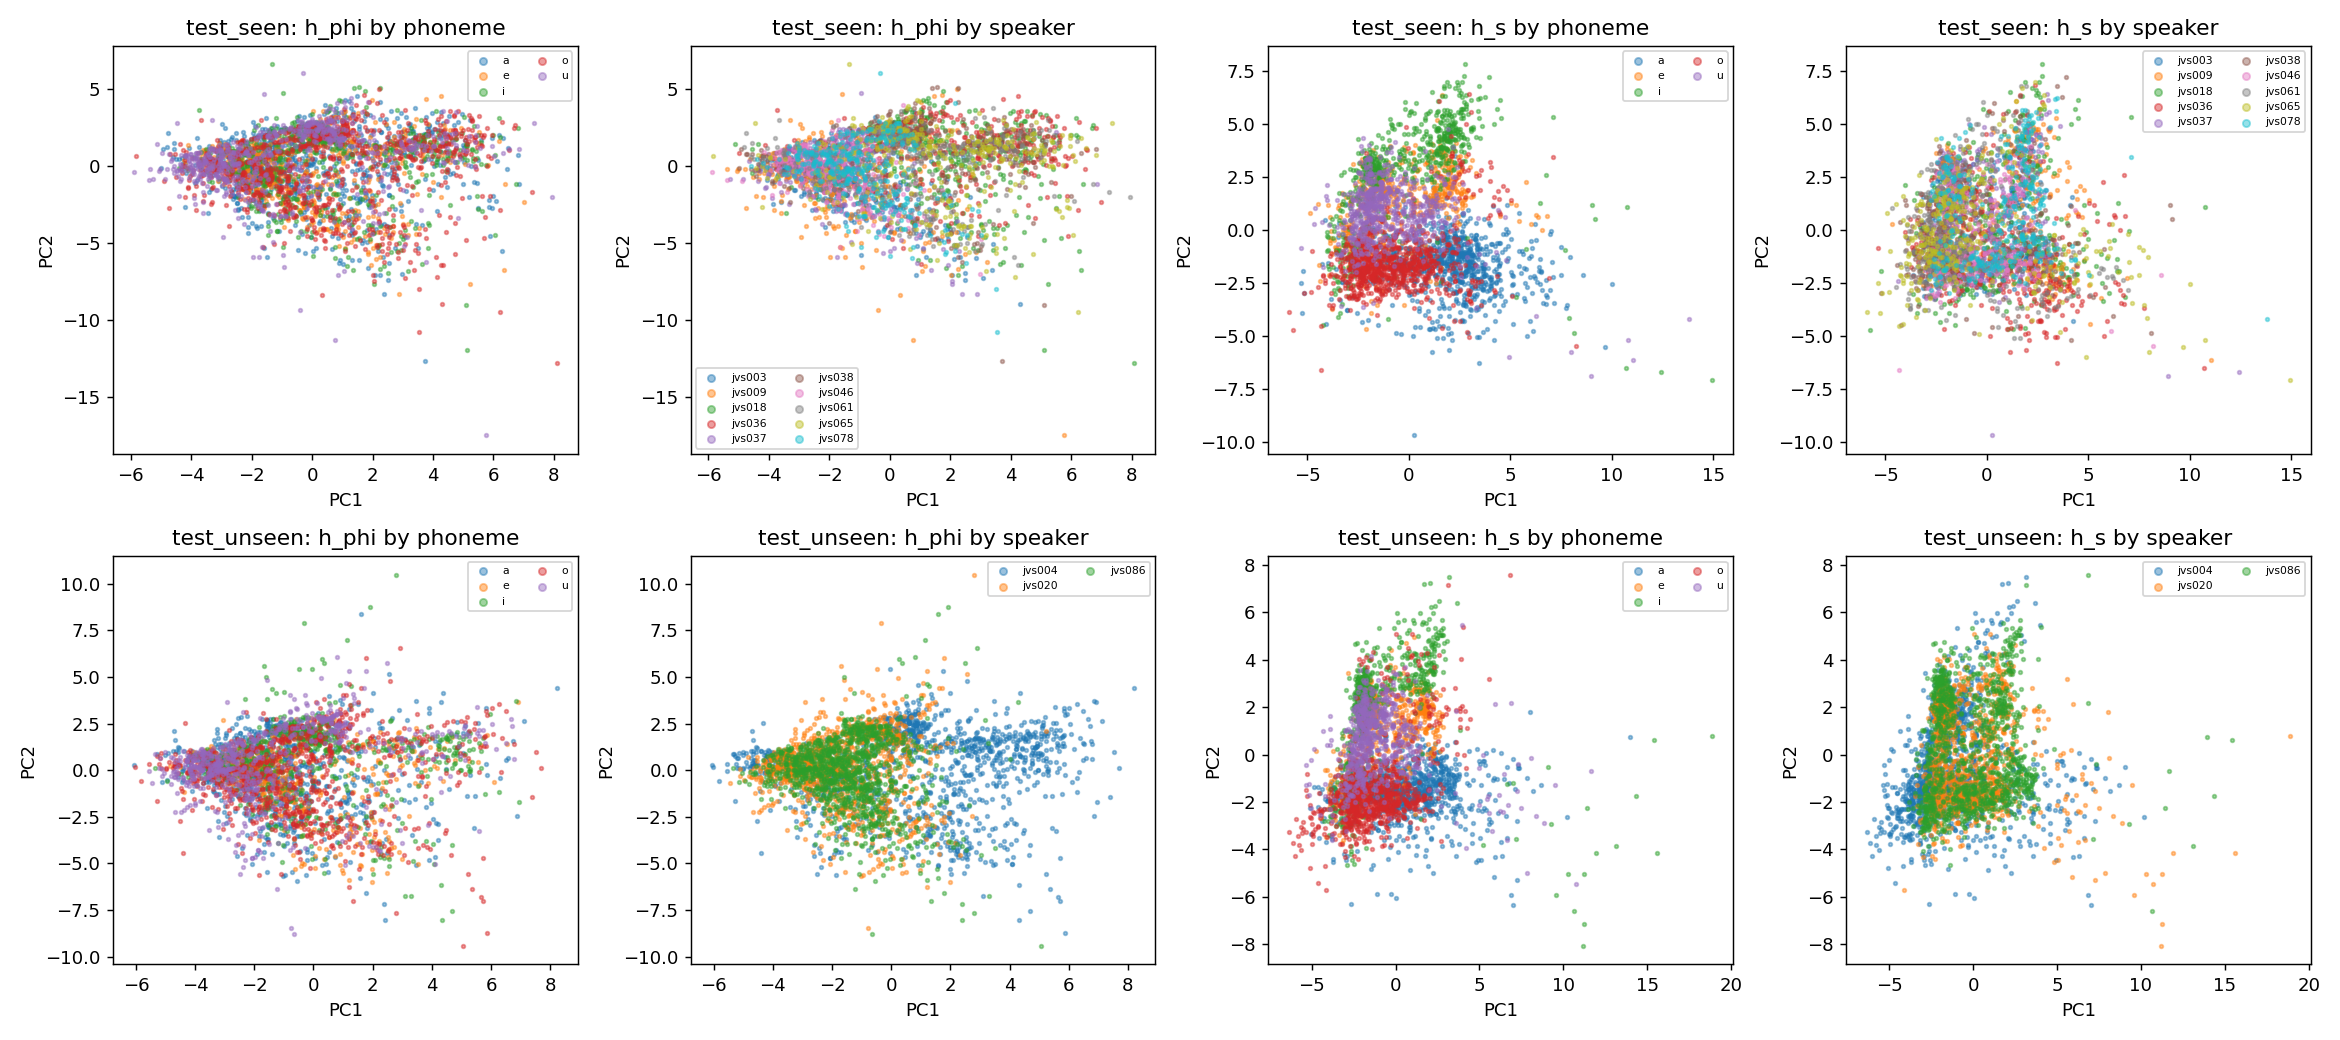

### Diagnostic example: B, prespecified seed 42

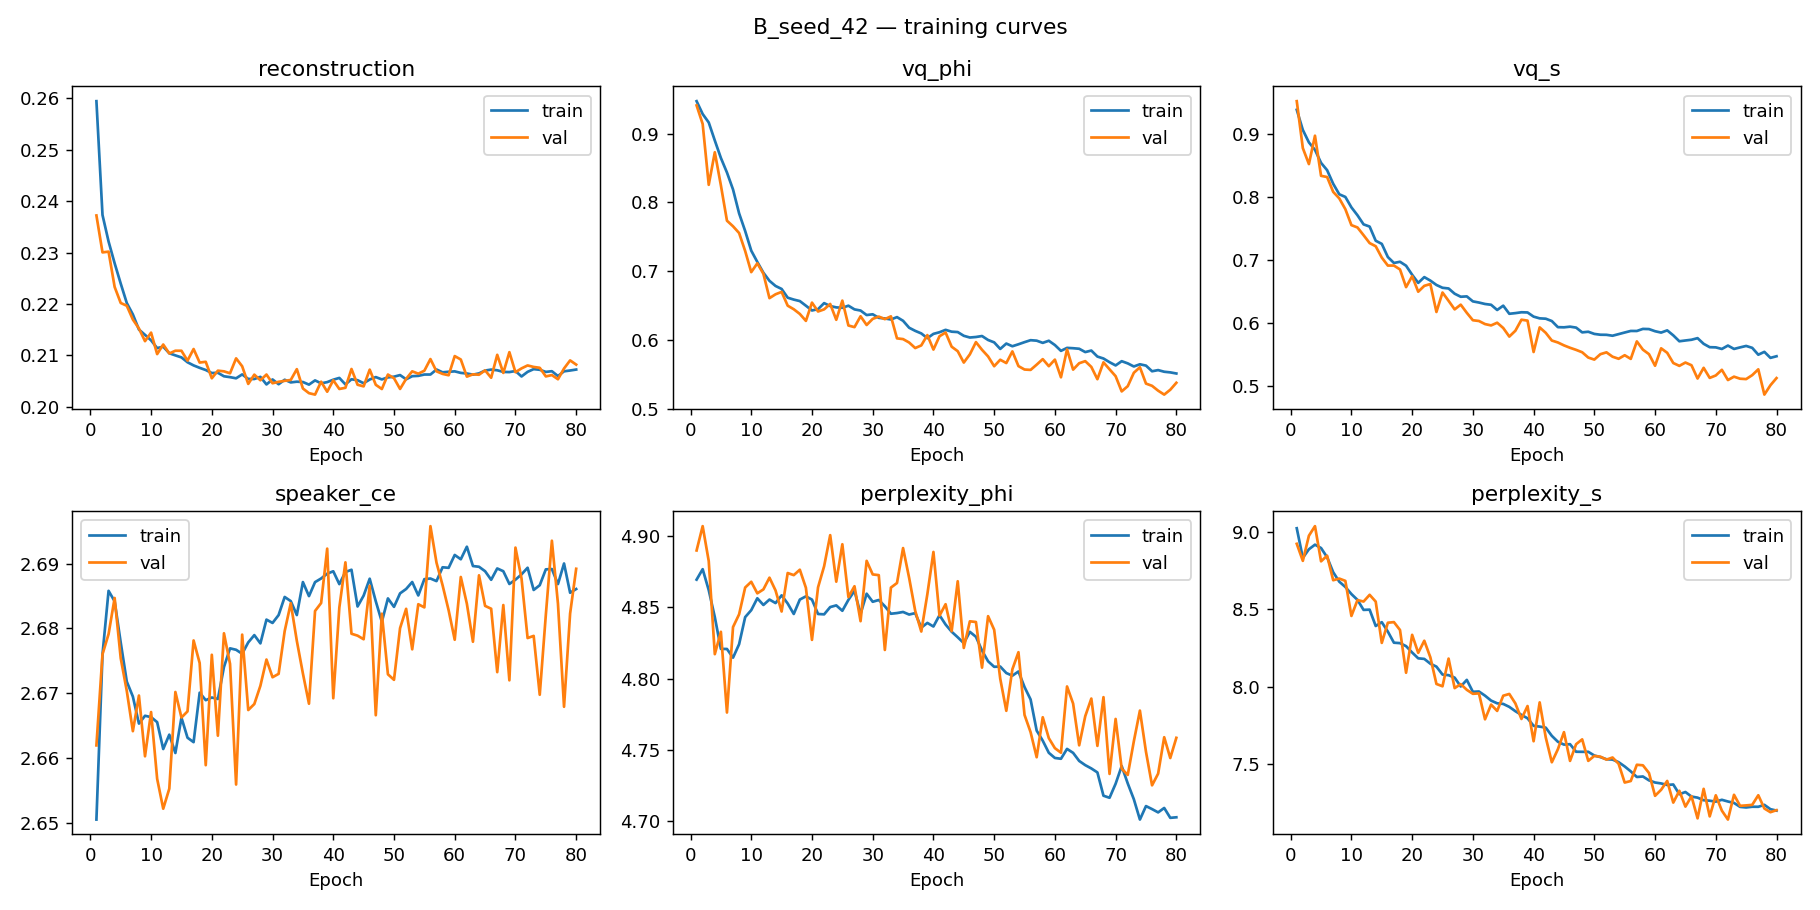

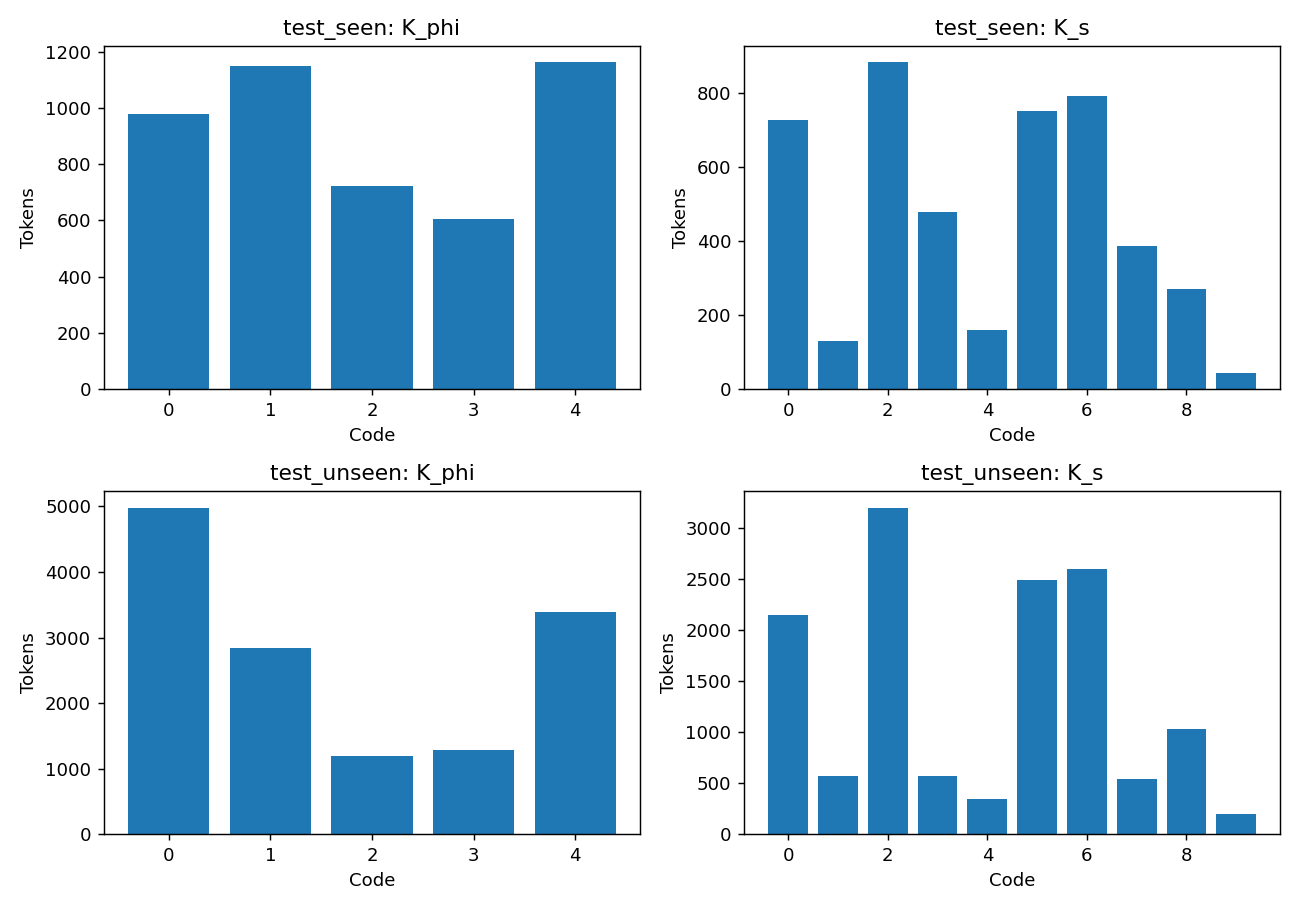

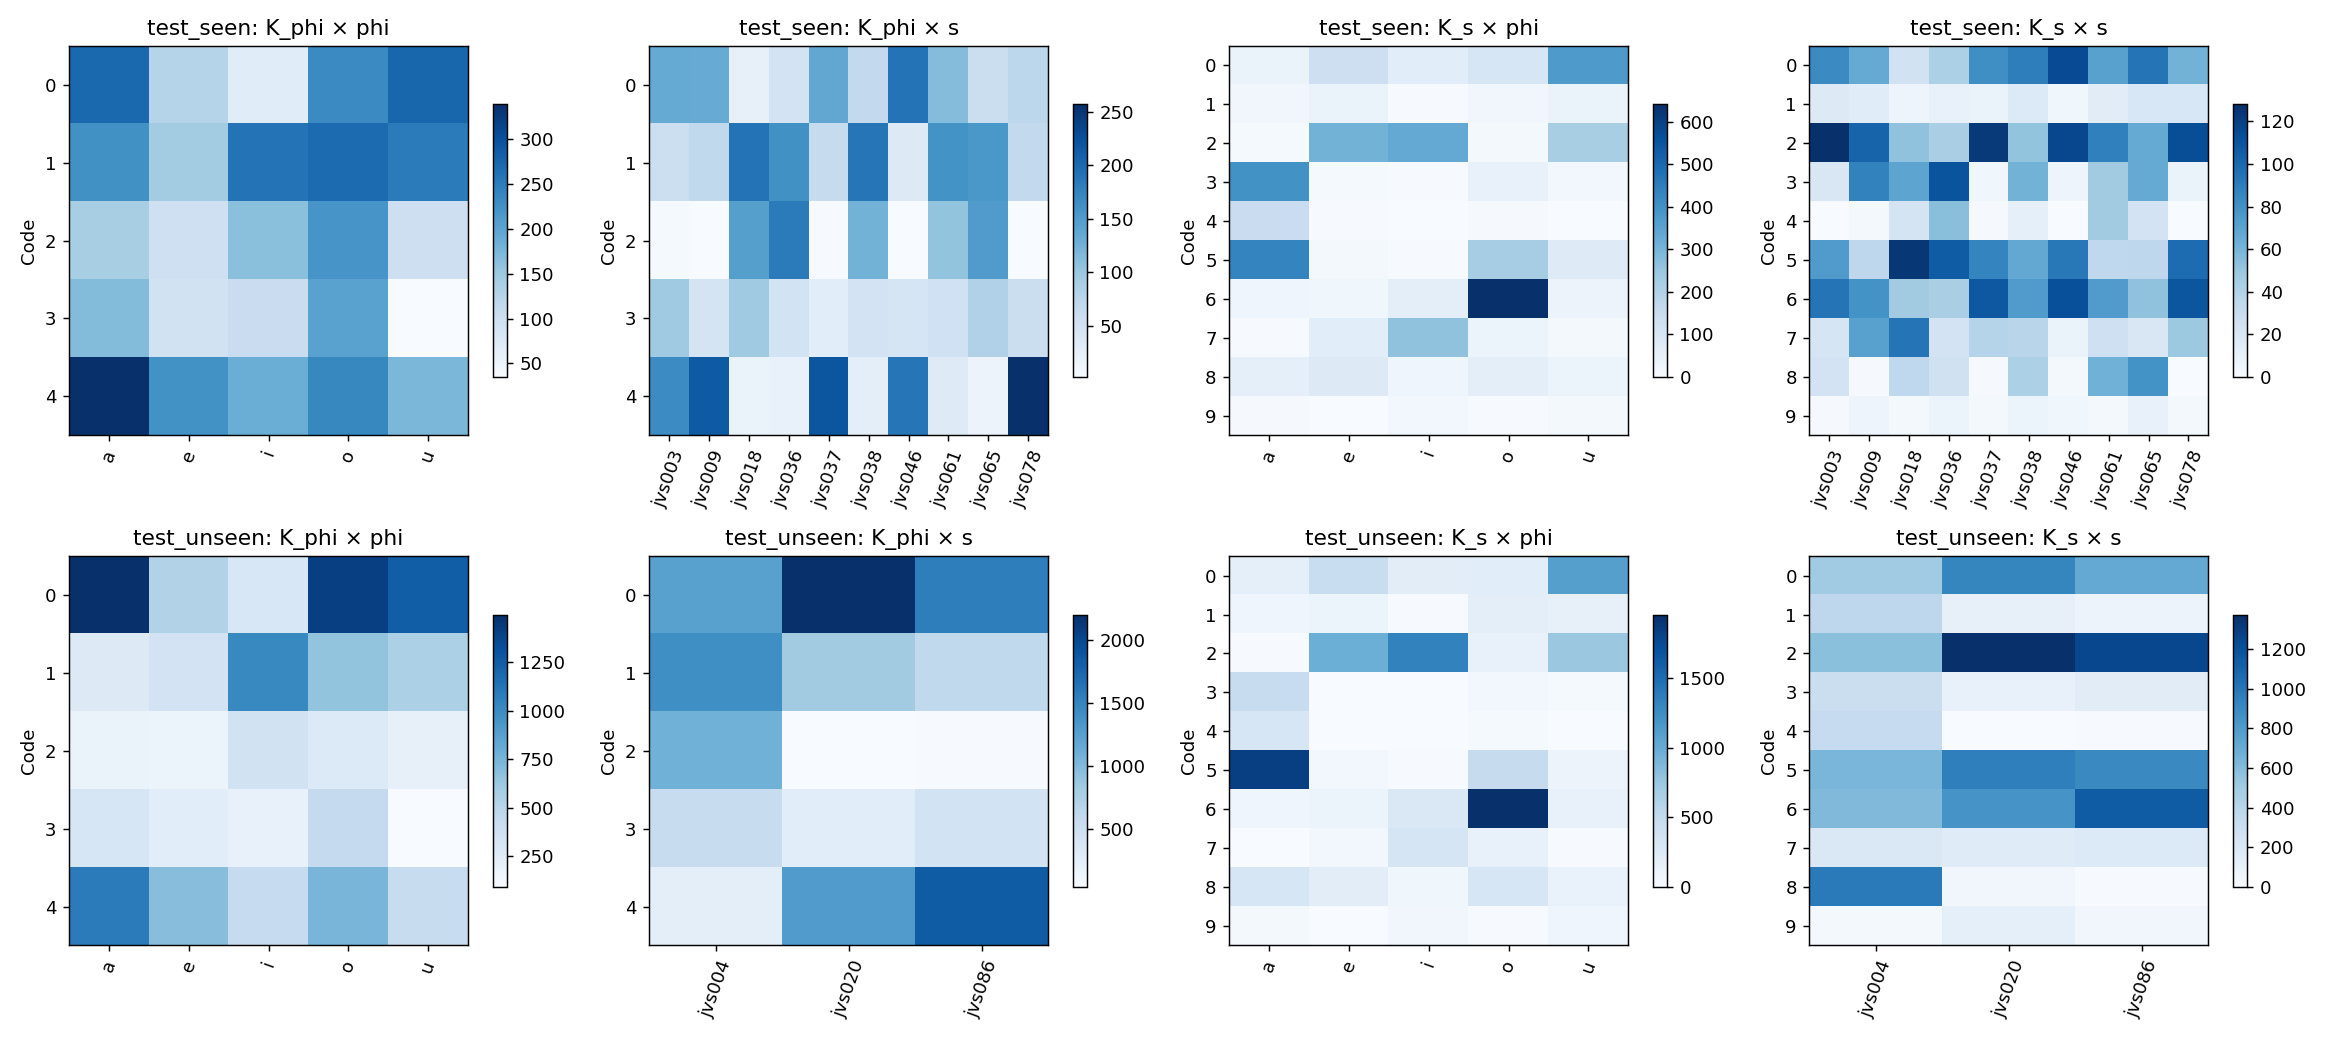

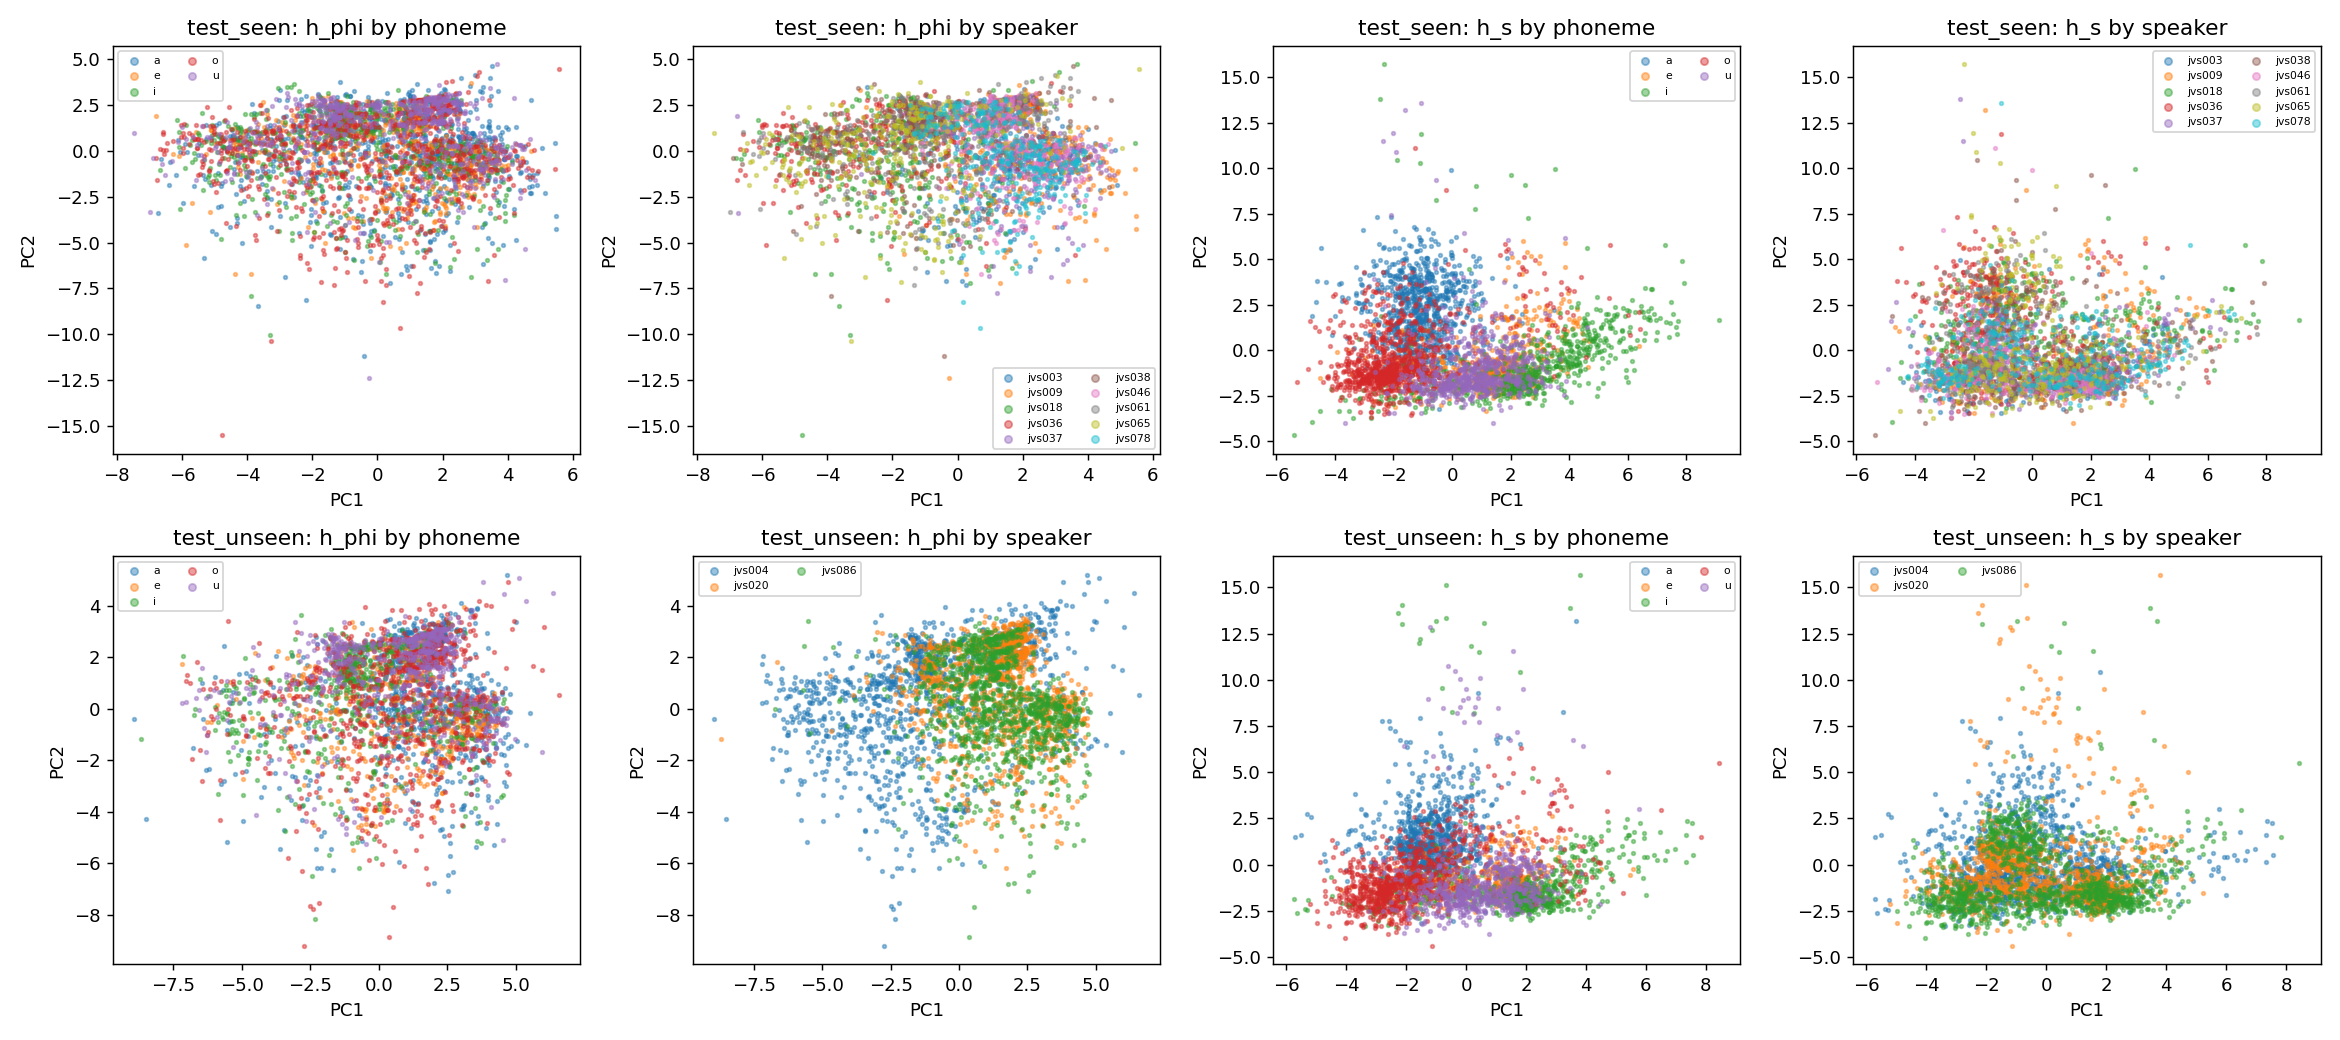

In [5]:
from src.vq_report import make_report
report_path = make_report(run_dir)
display(Image(filename=str(run_dir/'figures/paired_effects.png')))
display(Image(filename=str(run_dir/'figures/feature_reconstruction.png')))
report_text = report_path.read_text(encoding='utf-8')
display(Markdown('\n'.join(line for line in report_text.splitlines() if not line.startswith('!['))))
for condition in ('A','B'):
    display(Markdown(f'### Diagnostic example: {condition}, prespecified seed {config.seeds[0]}'))
    for plot in ('learning','occupancy','contingencies','pca'):
        display(Image(filename=str(run_dir/'final'/f'{condition}_seed_{config.seeds[0]}'/'figures'/f'{plot}.png')))

## Reproducibility check
Reload the first prespecified final checkpoint, reproduce its test predictions exactly, and verify the matched initialization/order records. Configuration changes require a fresh run; resuming validates the dataset hash, configuration, and training source hashes. The mean-code decoder ablation uses only training population means. PCA is fitted only on training h_phi/h_s.

In [6]:
import numpy as np
from src.vq_data import prepare_vq_data
from src.vq_training import load_vq, predict_vq
from src.training import seed_everything
from threadpoolctl import threadpool_limits
data = prepare_vq_data(config)
seed_everything(config.seeds[0], config.threads)
directory = run_dir/'final'/f'A_seed_{config.seeds[0]}'
model, checkpoint = load_vq(directory, config)
with threadpool_limits(config.threads):
    prediction = predict_vq(model, data.x['test_unseen'])
saved = np.load(directory/'test_unseen_representations.npz')
for key in ('k_phi','k_s','reconstruction'):
    np.testing.assert_array_equal(prediction[key], saved[key])
for seed in config.seeds:
    pair = [json.loads((run_dir/'final'/f'{c}_seed_{seed}'/'validation.json').read_text()) for c in ('A','B')]
    for key in ('initial_state_sha256','minibatch_order_sha256'):
        assert pair[0][key] == pair[1][key]
print('Saved checkpoint exactly reproduces unseen-test assignments and reconstruction; all A/B hashes match.')
print('Report:', report_path)

C:\Users\46021\.conda\envs\lffl\Lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Saved checkpoint exactly reproduces unseen-test assignments and reconstruction; all A/B hashes match.
Report: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\dual_vq\20260928_190154_268b85\REPORT.md
